<a href="https://colab.research.google.com/github/pomellonn/ML-algorithms/blob/main/hierarchical_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Методы иерархической кластеризации

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt


## Координаты точек

In [11]:
import numpy as np

X= np.array([
    [0, 0],
    [2, 4],
    [3, 3],
    [1, 2],
    [3, 0],
    [3, 1],
    [1, 1],
    [12, 18],
    [13, 17],
    [11, 15],
    [13, 14],
    [14, 16],
    [11, 16],
    [12, 15],
    [13, 18],
    [12, 5],
    [13, 2],
    [14, 4],
    [12, 3],
    [13, 1],
    [14, 2],
    [24, 19],
    [22, 22],
    [21, 24],
    [23, 21],
    [24, 20],
    [22, 39],
    [23, 38],
    [21, 37],
    [2, 26],
    [24, 6],
    [10, 36],
    [24, 39]
], dtype=int)

## Метод одиночной связи

### Дендрограмма

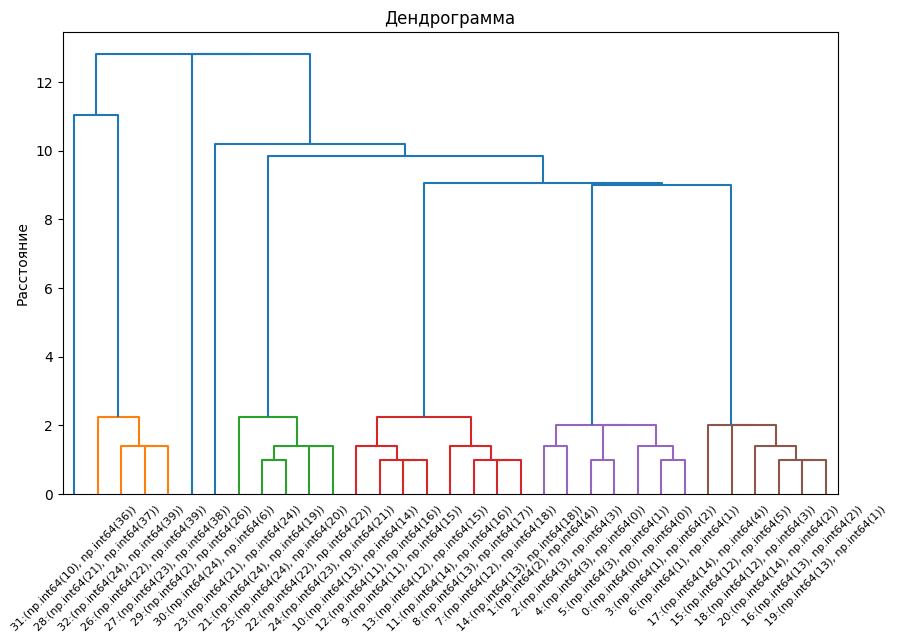

In [12]:
single_method = linkage(X, method='single')
plt.figure(figsize=(10, 6))
dendrogram(single_method, labels=[f"{i}:{tuple(p)}" for i, p in enumerate(X)])
plt.title("Дендрограмма")
plt.ylabel("Расстояние")
plt.show()

### Кортеж минимальных расстояний

In [25]:
for row in single_method:
    print(int(row[0]), int(row[1]), round(row[2], 4))

3 6 1.0
4 5 1.0
16 19 1.0
20 35 1.0
9 13 1.0
12 37 1.0
7 14 1.0
8 39 1.0
21 25 1.0
0 33 1.4142
1 2 1.4142
18 36 1.4142
10 38 1.4142
11 40 1.4142
22 24 1.4142
41 47 1.4142
26 27 1.4142
32 49 1.4142
34 42 2.0
43 51 2.0
15 44 2.0
17 53 2.0
45 46 2.2361
23 48 2.2361
28 50 2.2361
52 54 9.0
55 58 9.0554
56 59 9.8489
30 60 10.198
31 57 11.0454
29 61 12.8062
62 63 12.8062


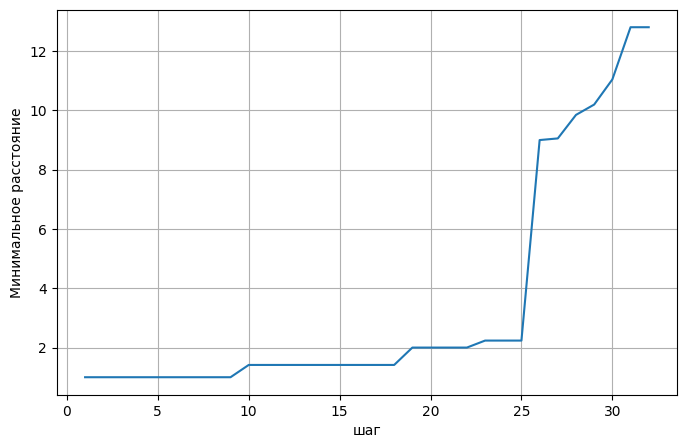

In [14]:
min_dists = single_method[:, 2]

steps = np.arange(1, len(single_method) + 1)
plt.figure(figsize=(8, 5))
plt.plot(steps, min_dists)
plt.xlabel("шаг")
plt.ylabel("Минимальное расстояние")
plt.grid(True)
plt.show()

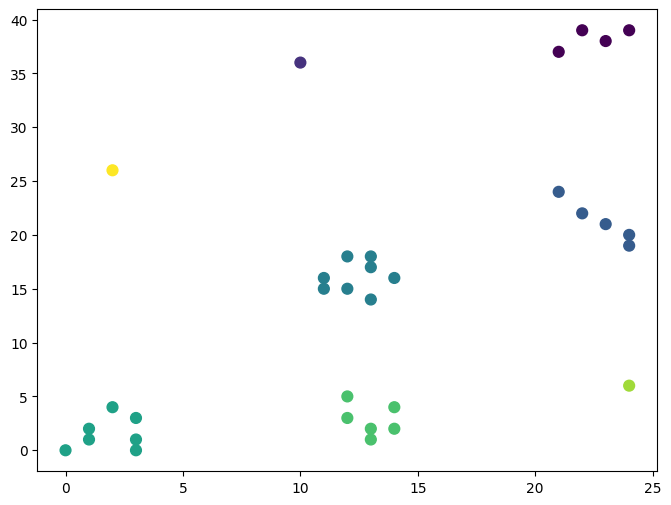

In [15]:
n_clusters = 8
labels = fcluster(single_method, t=n_clusters, criterion='maxclust')

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, s=60)
plt.show()

## Метод Уорда

### Дендрограмма

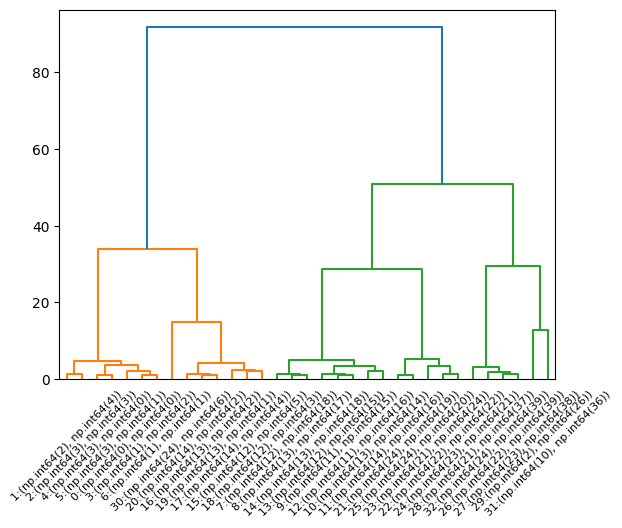

In [16]:
ward_method = linkage(X, method='ward')
dendrogram(ward_method, labels=[f"{i}:{tuple(p)}" for i, p in enumerate(X)])
plt.show()

### Кортеж минимальных расстояний

In [21]:
for row in ward_method:
    print(int(row[0]), int(row[1]), round(row[2], 4))

3 6 1.0
4 5 1.0
16 19 1.0
9 12 1.0
8 14 1.0
21 25 1.0
20 35 1.291
13 36 1.291
7 37 1.291
1 2 1.4142
26 27 1.4142
22 24 1.4142
32 43 1.8257
15 18 2.0
0 33 2.0817
10 11 2.2361
17 46 2.3094
28 45 3.1885
23 44 3.3665
40 48 3.3961
34 47 3.6968
39 49 4.2032
42 53 4.8107
41 52 4.8614
38 51 5.3728
29 31 12.8062
30 54 14.9873
56 57 28.7628
50 58 29.4307
55 59 33.9432
60 61 50.9098
62 63 91.7146


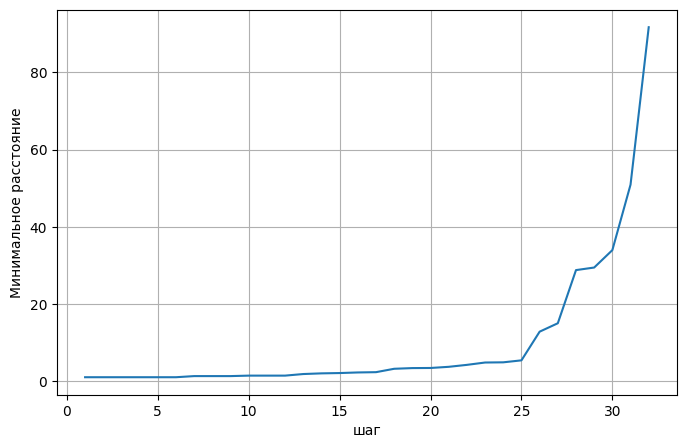

In [26]:
min_dists = ward_method[:, 2]

steps = np.arange(1, len(ward_method) + 1)
plt.figure(figsize=(8, 5))
plt.plot(steps, min_dists)
plt.xlabel("шаг")
plt.ylabel("Минимальное расстояние")
plt.grid(True)
plt.show()

## Метод Центроид

### Дендрограмма

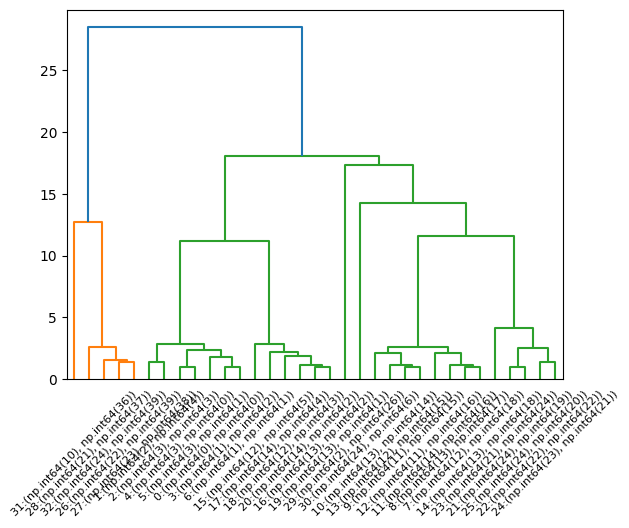

In [17]:
centroid_method = linkage(X, method='centroid')
dendrogram(centroid_method, labels=[f"{i}:{tuple(p)}" for i, p in enumerate(X)])
plt.show()

### Кортеж минимальных расстояний

In [22]:
for row in centroid_method:
    print(int(row[0]), int(row[1]), round(row[2], 4))

3 6 1.0
7 14 1.0
16 19 1.0
4 5 1.0
9 12 1.0
21 25 1.0
20 35 1.118
8 34 1.118
13 37 1.118
1 2 1.4142
22 24 1.4142
26 27 1.4142
32 44 1.5811
0 33 1.8028
18 39 1.8856
10 41 2.1344
11 40 2.1344
17 47 2.2361
36 46 2.3863
38 43 2.5
48 49 2.5739
28 45 2.6034
42 51 2.846
15 50 2.8636
23 52 4.1608
55 56 11.2141
53 57 11.5947
31 54 12.7009
30 59 14.2775
29 61 17.322
58 62 18.0168
60 63 28.4748


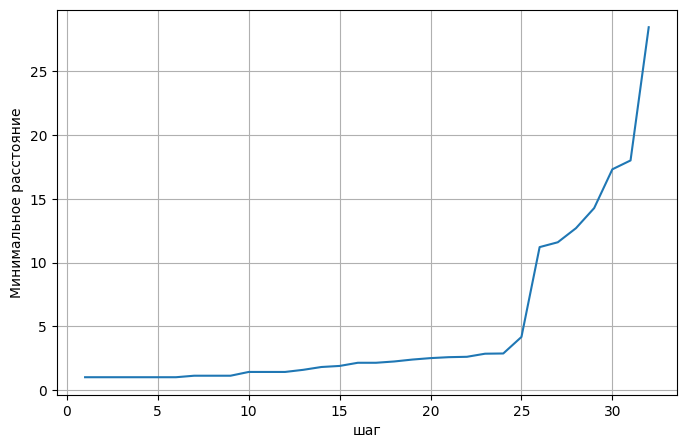

In [27]:
min_dists = centroid_method[:, 2]

steps = np.arange(1, len(centroid_method) + 1)
plt.figure(figsize=(8, 5))
plt.plot(steps, min_dists)
plt.xlabel("шаг")
plt.ylabel("Минимальное расстояние")
plt.grid(True)
plt.show()

## Метод полной связи

### Дендрограмма

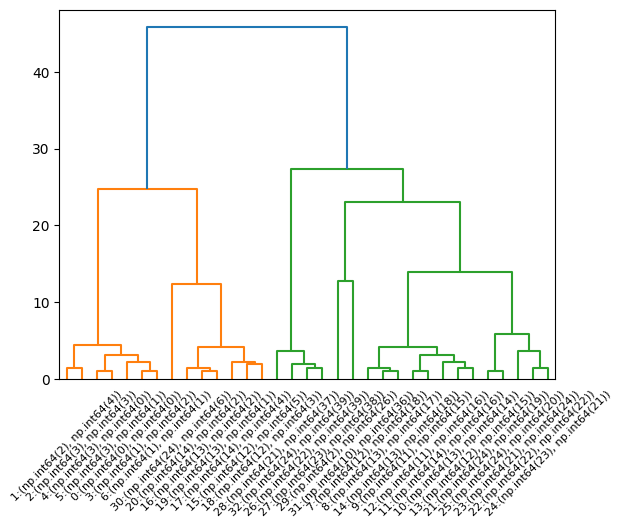

In [18]:
complete_method = linkage(X, method='complete')
dendrogram(complete_method, labels=[f"{i}:{tuple(p)}" for i, p in enumerate(X)])
plt.show()

### Кортеж минимальных расстояний

In [23]:
for row in complete_method:
    print(int(row[0]), int(row[1]), round(row[2], 4))

3 6 1.0
4 5 1.0
16 19 1.0
9 12 1.0
8 14 1.0
21 25 1.0
1 2 1.4142
20 35 1.4142
10 13 1.4142
7 37 1.4142
22 24 1.4142
26 27 1.4142
15 18 2.0
32 44 2.0
0 33 2.2361
17 45 2.2361
11 41 2.2361
34 47 3.1623
36 49 3.1623
23 43 3.6056
28 46 3.6056
40 48 4.1231
42 51 4.1231
39 50 4.4721
38 52 5.831
30 54 12.3693
29 31 12.8062
55 57 13.9284
59 60 23.0868
56 58 24.7386
53 61 27.313
62 63 45.793


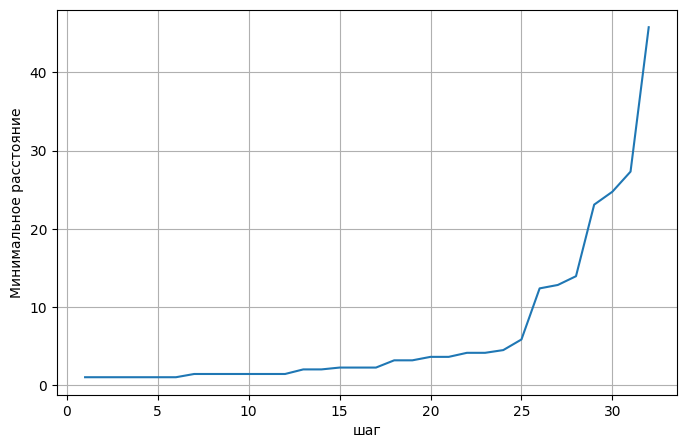

In [28]:
min_dists = complete_method[:, 2]

steps = np.arange(1, len(complete_method) + 1)
plt.figure(figsize=(8, 5))
plt.plot(steps, min_dists)
plt.xlabel("шаг")
plt.ylabel("Минимальное расстояние")
plt.grid(True)
plt.show()

## Метод средней связи

### Дендрограмма

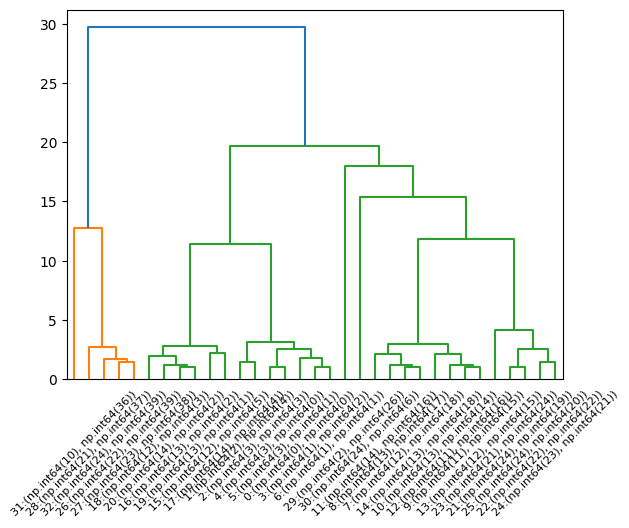

In [19]:
average_method = linkage(X, method='average')
dendrogram(average_method, labels=[f"{i}:{tuple(p)}" for i, p in enumerate(X)])
plt.show()

### Кортеж минимальных расстояний

In [24]:
for row in average_method:
    print(int(row[0]), int(row[1]), round(row[2], 4))

3 6 1.0
4 5 1.0
16 19 1.0
9 13 1.0
7 14 1.0
21 25 1.0
20 35 1.2071
12 36 1.2071
8 37 1.2071
1 2 1.4142
22 24 1.4142
26 27 1.4142
32 44 1.7071
0 33 1.8251
18 39 1.9621
11 41 2.1596
10 40 2.1596
15 17 2.2361
38 43 2.5211
34 46 2.5771
28 45 2.6926
47 50 2.8157
48 49 2.9408
42 52 3.1463
23 51 4.1681
54 56 11.3833
55 57 11.8406
31 53 12.7214
30 59 15.3975
29 61 17.983
58 62 19.6885
60 63 29.7035


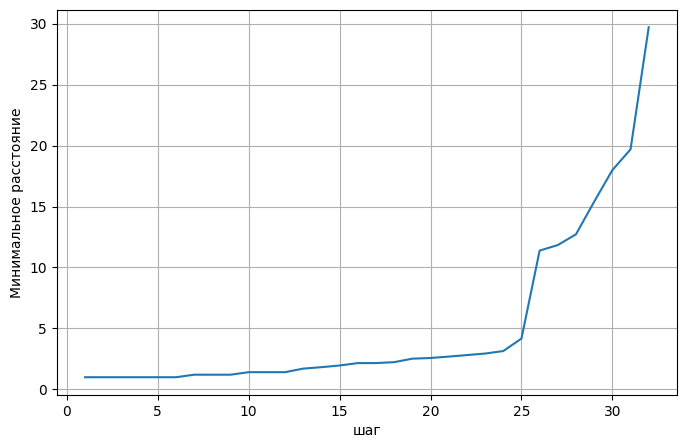

In [29]:
min_dists = average_method[:, 2]

steps = np.arange(1, len(average_method) + 1)
plt.figure(figsize=(8, 5))
plt.plot(steps, min_dists)
plt.xlabel("шаг")
plt.ylabel("Минимальное расстояние")
plt.grid(True)
plt.show()